In [47]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from opacus import PrivacyEngine

In [48]:
df = pd.read_csv("Final_Depression1_anonymised.csv")
print("Shape:", df.shape)
df.head()

Shape: (11670, 39)


,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,orientation,race,...,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,Condition
0,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_bdb4a209,TKN_92b09c7c,TKN_05b81f76,TKN_1b5799db,TKN_25a81701,...,2,5,6,6,6,6,5,2,1,Extremely Severe
1,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_1b5799db,TKN_25a81701,...,2,5,7,7,5,5,5,3,5,Mild
2,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,1,7,5,6,7,7,1,7,5,Mild
3,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,7,5,7,6,5,6,2,1,1,Severe
4,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,4,3,6,4,6,4,5,3,3,Normal


In [49]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}
target_column = 'Condition'

# Encode all categorical columns except the target
for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Encode the target as well
le_target = LabelEncoder()
df_encoded[target_column] = le_target.fit_transform(df_encoded[target_column])

# Now split from df_encoded
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)



In [50]:
# Check and encode any remaining non-numeric features
for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])

# Now retry SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [51]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to PyTorch tensors (make sure all are numeric)
X_train_tensor = torch.tensor(X_train_sm.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sm, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



In [52]:
# !pip install diffprivlib
# !pip install imbalanced-learn

In [53]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
model = MLP(input_dim, num_classes)




In [54]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)


In [55]:
best_val_loss = float('inf')
patience = 25         # Stop after 3 epochs of no improvement
counter = 0
max_epochs = 50       # Max cap in case it doesn't converge

for epoch in range(max_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

    print(f"Epoch {epoch+1} - Training Loss: {total_loss:.4f} - Validation Loss: {val_loss:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "trained_mlp_model.pth")  # Save best model
        print("New best model saved!")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping: No improvement for 3 consecutive epochs.")
            break


Epoch 1 - Training Loss: 344.6390 - Validation Loss: 1.0018
✅ New best model saved!
Epoch 2 - Training Loss: 242.6912 - Validation Loss: 0.7765
✅ New best model saved!
Epoch 3 - Training Loss: 211.2974 - Validation Loss: 0.7009
✅ New best model saved!
Epoch 4 - Training Loss: 195.6264 - Validation Loss: 0.7038
Epoch 5 - Training Loss: 184.7494 - Validation Loss: 0.7096
Epoch 6 - Training Loss: 181.2373 - Validation Loss: 0.6982
✅ New best model saved!
Epoch 7 - Training Loss: 176.4937 - Validation Loss: 0.7017
Epoch 8 - Training Loss: 178.6332 - Validation Loss: 0.7916
Epoch 9 - Training Loss: 194.2880 - Validation Loss: 0.8008
Epoch 10 - Training Loss: 197.3246 - Validation Loss: 0.9096
Epoch 11 - Training Loss: 206.1193 - Validation Loss: 0.9657
Epoch 12 - Training Loss: 201.4763 - Validation Loss: 0.9483
Epoch 13 - Training Loss: 212.8724 - Validation Loss: 0.9048
Epoch 14 - Training Loss: 205.2883 - Validation Loss: 0.8730
Epoch 15 - Training Loss: 208.7413 - Validation Loss: 0.918

In [56]:
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_tensor).argmax(dim=1)
    y_val_pred = model(X_val_tensor).argmax(dim=1)

train_acc = accuracy_score(y_train_tensor, y_train_pred)
val_acc = accuracy_score(y_val_tensor, y_val_pred)

print(f"\n Training Accuracy: {train_acc:.4f}")
print(f" Validation Accuracy: {val_acc:.4f}\n")

print("Classification Report (Validation):")
print(classification_report(y_val_tensor, y_val_pred, target_names=[str(c) for c in le_target.classes_]))


epsilon = privacy_engine.accountant.get_epsilon(delta=1e-5)
print(f"\n Differential Privacy Epsilon: {epsilon:.2f} (δ=1e-5)")




✅ Training Accuracy: 0.7853
✅ Validation Accuracy: 0.7674

📊 Classification Report (Validation):
                  precision    recall  f1-score   support

Extremely Severe       0.94      0.87      0.90       794
            Mild       0.46      0.70      0.55       220
        Moderate       0.74      0.65      0.69       432
          Normal       0.99      0.72      0.84       511
          Severe       0.59      0.79      0.67       377

        accuracy                           0.77      2334
       macro avg       0.74      0.75      0.73      2334
    weighted avg       0.81      0.77      0.78      2334


🔐 Differential Privacy Epsilon: 1.92 (δ=1e-5)


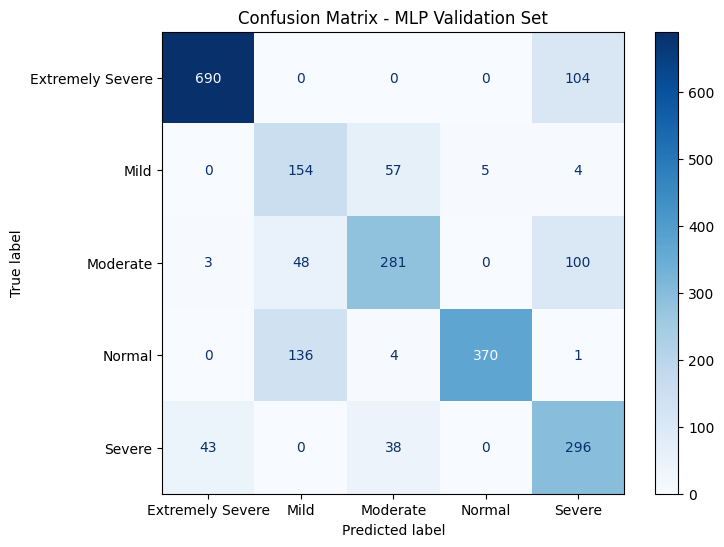

In [57]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# STEP 1: Predict using the trained MLP model
model.eval()
with torch.no_grad():
    y_val_logits = model(X_val_tensor)
    y_val_pred = torch.argmax(y_val_logits, dim=1).cpu().numpy()

# STEP 2: Optional - decode integer labels to original class names if you used LabelEncoder
class_labels = [str(cls) for cls in le_target.classes_]  # Converts int64 to string labels

# STEP 3: Generate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# STEP 4: Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - MLP Validation Set")
plt.show()


In [58]:
# Run in terminal or ! in Jupyter
!pip install tenseal

In [59]:
import tenseal as ts
import numpy as np
import torch

In [60]:
import tenseal as ts
print(ts.__version__)


0.3.16


In [61]:
# Simulate a dummy gradient from a layer (e.g., 5 parameters)
local_gradient = torch.tensor([0.25, -0.3, 0.1, 0.55, -0.12], dtype=torch.float32)

print("Original Gradient (Local Model):")
print(local_gradient.numpy())


📈 Original Gradient (Local Model):
[ 0.25 -0.3   0.1   0.55 -0.12]


In [62]:
# import torch
# import tenseal as ts
# import numpy as np

# def print_raw_gradients(model):
#     print("\n Raw Gradients Before Encryption:")
#     for name, param in model.named_parameters():
#         if param.requires_grad and param.grad is not None:
#             grad = param.grad.view(-1).detach().cpu().numpy()
#             print(f"\n Layer: {name}")
#             print(f"   Gradient Shape: {grad.shape}")
#             print(f"   Sample Values: {grad[:5]}")
#             print("-" * 50)

# def encrypt_gradients_from_model(model, X_batch, y_batch, loss_fn, context):
#     model.train()
#     model.zero_grad()

#     # Forward + Backward Pass
#     outputs = model(X_batch)
#     loss = loss_fn(outputs, y_batch)
#     loss.backward()  # Only once!

#     # Print raw gradients before encryption
#     print_raw_gradients(model)

#     encrypted_grads = {}

#     for name, param in model.named_parameters():
#         if param.requires_grad and param.grad is not None:
#             grad = param.grad.view(-1).detach().cpu().numpy()
#             enc_grad = ts.ckks_vector(context, grad.tolist())
#             encrypted_grads[name] = enc_grad

#             print(f"\n Encrypted Gradient for {name} — sample decrypted view:")
#             print(enc_grad.decrypt()[:5])

#     return encrypted_grads
# # Example call (make sure this is included below the function definition)
# encrypted_grads = encrypt_gradients_from_model(model, X_batch, y_batch, loss_fn, public_context)



In [63]:
# CKKS encryption context setup
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.generate_galois_keys()
context.global_scale = 2**40

# Save public & secret key (just for simulation; normally private key stays secure)
public_context = context.copy()  # This is what would be shared with the server
public_context.make_context_public()  # Only allows encryption
with open("context.ser", "wb") as f:
    f.write(public_context.serialize())


In [64]:
import torch

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [65]:
def encrypt_gradients_from_model(model, X_batch, y_batch, loss_fn, context):
    model.train()
    model.zero_grad()

    outputs = model(X_batch)
    loss = loss_fn(outputs, y_batch)
    loss.backward()

    encrypted_grads = {}

    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad = param.grad.view(-1).detach().cpu().numpy()
            enc_grad = ts.ckks_vector(context, grad.tolist())
            encrypted_grads[name] = enc_grad

            print(f"\n Layer: {name}")
            print(f"   Original Gradient Sample: {grad[:5]}")
            print(f"   Encrypted Gradient Sample (decrypted view): {enc_grad.decrypt()[:5]}")

    return encrypted_grads

In [66]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

# Get one batch from your train loader
X_sample, y_sample = next(iter(train_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

# Run encryption on gradients
encrypted_grads = encrypt_gradients_from_model(model, X_sample, y_sample, loss_fn, context)


The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.

🔹 Layer: _module.model.0.weight
  🔸 Original Gradient Sample: [-5.4300264e-03 -6.2155649e-03  8.7658977e-05 -3.0960226e-03
 -2.0834286e-05]
  🔐 Encrypted Gradient Sample (decrypted view): [-0.00543002806376533, -0.006215564483952607, 8.766022581285782e-05, -0.003096020327384416, -2.0830613553568522e-05]

🔹 Layer: _module.model.0.bias
  🔸 Original Gradient Sample: [-0.00297443  0.         -0.07986141  0.         -0.01946617]
  🔐 Encrypted Gradient Sample (decrypted view): [-0.002974428928609735, 1.8739873176141067e-10, -0.07986141010078676, 2.813435161368083e-09, -0.019466166256670036]
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your 

In [67]:
# !pip install flask

In [68]:
import torch
import tenseal as ts
import pickle
import requests
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
IS_BYZANTINE = True
BYZANTINE_STRATEGY = "flip"  # or "random", "scale"

# -------------------------------
#  CKKS Setup
# -------------------------------
def get_ckks_context():
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    context.global_scale = 2**40
    context.generate_galois_keys()
    return context

ckks_context = get_ckks_context()
public_context = ckks_context.serialize(save_secret_key=False)

# -------------------------------
# Gradient Flattening
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    print(f"[DEBUG] Flattened gradient length: {len(flat)}")
    return flat

# ------------------------------------------
# Inject Byzantine Gradient Manipulation
# ------------------------------------------
def make_byzantine_gradients(grads, strategy="flip"):
    if strategy == "flip":
        print("[BYZANTINE] Flipping gradients (multiply by -1)...")
        return -1 * grads
    elif strategy == "scale":
        print("[BYZANTINE] Scaling gradients by 100...")
        return grads * 5000
    elif strategy == "random":
        print("[BYZANTINE] Replacing with random noise...")
        return torch.randn_like(grads)
    else:
        print("[BYZANTINE] Unknown strategy, sending original gradients.")
        return grads

# -------------------------------
# Encrypt Gradients with CKKS
# -------------------------------
def encrypt_gradients(flattened_grads, context, chunk_size=8000):
    if len(flattened_grads) > chunk_size:
        print("[WARNING] Gradient too large for single CKKS vector (>8192). Chunking.")
        chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    else:
        chunks = [flattened_grads]

    encrypted_chunks = []
    ctx = ts.context_from(context)
    ctx.make_context_public()

    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted_chunks.append(enc)
        print(f"[DEBUG] Encrypted chunk {i} with {len(chunk)} values")

    return encrypted_chunks

# -------------------------------
# Send Encrypted Chunks to Server
# -------------------------------
def send_encrypted_chunks_binary(encrypted_chunks, server_url, client_id="hospital_1"):
    for i, enc_chunk in enumerate(encrypted_chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id, 
                'data': enc_chunk.serialize()
            }
            data = pickle.dumps(payload)

            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False  
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")


# -------------------------------
# Client Main Routine
# -------------------------------
def run_client_post_training(model):
    print("[CLIENT] Preparing gradients...")
    grads = flatten_gradients(model)
    if IS_BYZANTINE:
        grads = make_byzantine_gradients(grads, strategy=BYZANTINE_STRATEGY)
    enc_chunks = encrypt_gradients(grads, public_context)

    print("[CLIENT] Sending encrypted gradients...")
    send_encrypted_chunks_binary(enc_chunks, server_url="https://127.0.0.1:5055")

run_client_post_training(model)

[CLIENT] 📦 Preparing gradients...
[DEBUG] Flattened gradient length: 13573
[BYZANTINE] Flipping gradients (multiply by -1)...
[WARNING] Gradient too large for single CKKS vector (>8192). Chunking.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values
[CLIENT] 🚀 Sending encrypted gradients...
[CLIENT] ✅ Sent chunk 0 (668777 bytes)
[CLIENT] ✅ Sent chunk 1 (668571 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [69]:
import torch
import torch.nn as nn
import pickle
import tenseal as ts
from sklearn.metrics import classification_report
import warnings
import os
import shutil
import requests

warnings.filterwarnings("ignore", category=UserWarning)
IS_BYZANTINE = True
BYZANTINE_STRATEGY = "flip"  # or "random", "scale"

# -------------------------------
# Define MLP Architecture
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, output_dim=5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# -------------------------------
#  Decrypt + Apply Global Gradient
# -------------------------------
def receive_and_update_model(model, ckks_context, global_gradient_file="aggregated_gradient_global_encrypted.pkl"):
    with open(global_gradient_file, "rb") as f:
        encrypted_chunks_serialized = pickle.load(f)

    decrypted_flattened_grad = []
    for i, chunk_ser in enumerate(encrypted_chunks_serialized):
        enc_chunk = ts.ckks_vector_from(ckks_context, chunk_ser)
        decrypted_chunk = torch.tensor(enc_chunk.decrypt(), dtype=torch.float32)
        decrypted_flattened_grad.append(decrypted_chunk)
        print(f"[CLIENT] Decrypted chunk {i} of size {len(decrypted_chunk)}")

    decrypted_gradient = torch.cat(decrypted_flattened_grad)
    print(f"[CLIENT] Total decrypted global gradient length: {len(decrypted_gradient)}")

    # Clip gradient norm if necessary
    grad_norm = decrypted_gradient.norm()
    if grad_norm > 1e2:
        decrypted_gradient = decrypted_gradient / grad_norm * 1e2
        print(f"[CLIENT] Gradient clipped to norm 1e2 (original norm: {grad_norm:.2e})")

    # Apply gradients to model
    pointer = 0
    for param in model.parameters():
        if param.grad is not None:
            param_shape = param.grad.shape
            param_size = param.grad.numel()
            grad_slice = decrypted_gradient[pointer:pointer + param_size].view(param_shape)
            param.data -= grad_slice
            pointer += param_size

    print("[CLIENT] Global model updated with aggregated global gradient")

# -------------------------------
# Evaluate Model
# -------------------------------
def evaluate_model(model, dataloader, criterion, split_name="Validation"):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = 100.0 * correct / total
    print(f"[CLIENT] {split_name} → Accuracy: {acc:.2f}%, Loss: {total_loss:.4f}")
    return all_preds, all_labels, total_loss

# -------------------------------
#  HE Gradient Send Helpers
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    return flat

# ------------------------------------------
#  Inject Byzantine Gradient Manipulation
# ------------------------------------------
def make_byzantine_gradients(grads, strategy="flip"):
    if strategy == "flip":
        print("[BYZANTINE] Flipping gradients (multiply by -1)...")
        return -1 * grads
    elif strategy == "scale":
        print("[BYZANTINE] Scaling gradients by 100...")
        return grads * 100
    elif strategy == "random":
        print("[BYZANTINE] Replacing with random noise...")
        return torch.randn_like(grads)
    else:
        print("[BYZANTINE] Unknown strategy, sending original gradients.")
        return grads


def encrypt_gradients(flattened_grads, context, chunk_size=8000):
    chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    encrypted_chunks = []
    ctx = ts.context_from(context)
    ctx.make_context_public()

    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted_chunks.append(enc)
        print(f"[DEBUG] Encrypted chunk {i} with {len(chunk)} values")
    return encrypted_chunks

def send_encrypted_chunks_binary(encrypted_chunks, server_url, client_id="hospital_1"):
    for i, enc_chunk in enumerate(encrypted_chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,
                'data': enc_chunk.serialize()
            }
            data = pickle.dumps(payload)
            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")

# -------------------------------
# Main Federated Loop 
# -------------------------------
ckks_context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
ckks_context.global_scale = 2**40
ckks_context.generate_galois_keys()
public_context = ckks_context.serialize(save_secret_key=False)

# Init model
sample_batch, _ = next(iter(train_loader))
input_dim = sample_batch.shape[1]
global_model = MLP(input_dim=input_dim, output_dim=5)
state_dict = torch.load("trained_mlp_model.pth")
fixed_state_dict = {k.replace("_module.", ""): v for k, v in state_dict.items()}
global_model.load_state_dict(fixed_state_dict, strict=False)
print("[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'")

# Toggle for Byzantine behavior
IS_BYZANTINE = True  # Set to True to simulate Byzantine client (hospital_1)
BYZANTINE_STRATEGY = "flip"  # Options: 'flip', 'scale', 'random'

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(global_model.parameters(), lr=0.01)

best_val_loss = float('inf')
patience = 3
counter = 0
max_rounds = 50

for round in range(max_rounds):
    print(f"\n === Federated Round {round+1} ===")

    # STEP 1: Local training
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 2: Wait for global gradient
    user_in = input("Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'): ").strip().lower()
    if user_in == "exit":
        print("Exiting federated training loop.")
        break

    # STEP 3: Apply global gradient
    receive_and_update_model(global_model, ckks_context)

    # STEP 4: Re-train model (after update)
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 5: Send new gradients
    print("[CLIENT] Encrypting & sending updated gradients...")
    grads = flatten_gradients(global_model)
    if IS_BYZANTINE:
        grads = make_byzantine_gradients(grads, strategy=BYZANTINE_STRATEGY)
    encrypted_chunks = encrypt_gradients(grads, public_context)
    send_encrypted_chunks_binary(encrypted_chunks, server_url="https://127.0.0.1:5055", client_id="hospital_1")

    # STEP 6: Evaluation
    evaluate_model(global_model, train_loader, criterion, "Training")
    val_preds, val_labels, val_loss = evaluate_model(global_model, val_loader, criterion, "Validation")
    print("[CLIENT] Validation Classification Report:")
    print(classification_report(val_labels, val_preds, zero_division=0))

    # STEP 7: Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(global_model.state_dict(), "trained_global_model_1.pth")
        print("Best model saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break

📦 [CLIENT] Loaded local model weights from 'trained_mlp_model.pth'

🔁 === Federated Round 1 ===


📥 Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'):  


[CLIENT] ✅ Decrypted chunk 0 of size 6787
[CLIENT] ✅ Decrypted chunk 1 of size 6786
[CLIENT] 🧠 Total decrypted global gradient length: 13573
[CLIENT] ⚠️ Gradient clipped to norm 1e2 (original norm: inf)
[CLIENT] 🚀 Global model updated with aggregated global gradient
[CLIENT] 🚀 Encrypting & sending updated gradients...
[BYZANTINE] Flipping gradients (multiply by -1)...
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values
[CLIENT] ✅ Sent chunk 0 (668909 bytes)
[CLIENT] ✅ Sent chunk 1 (668420 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] 📊 Training → Accuracy: 76.38%, Loss: 139.0472
[CLIENT] 📊 Validation → Accuracy: 76.65%, Loss: 20.0538
[CLIENT] 📝 Validation Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       794
           1       0.47      0.77      0.59       220
           2       0.72      0.60      0.66       432
           3       0.98      0.78      0.87       511
           4       0.59      0.70      0.64       377

    accuracy                           0.77      2334
   macro avg       0.74      0.75      0.73      2334
weighted avg       0.80      0.77      0.78      2334

✅ Best model saved.

🔁 === Federated Round 2 ===


...

[CLIENT] 📊 Training → Accuracy: 82.03%, Loss: 103.9072
[CLIENT] 📊 Validation → Accuracy: 80.03%, Loss: 16.9616
[CLIENT] 📝 Validation Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       794
           1       0.49      0.58      0.53       220
           2       0.73      0.71      0.72       432
           3       0.99      0.77      0.87       511
           4       0.67      0.75      0.71       377

    accuracy                           0.80      2334
   macro avg       0.76      0.75      0.75      2334
weighted avg       0.82      0.80      0.80      2334


🔁 === Federated Round 9 ===


📥 Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'):  


[CLIENT] ✅ Decrypted chunk 0 of size 6787
[CLIENT] ✅ Decrypted chunk 1 of size 6786
[CLIENT] 🧠 Total decrypted global gradient length: 13573
[CLIENT] ⚠️ Gradient clipped to norm 1e2 (original norm: inf)
[CLIENT] 🚀 Global model updated with aggregated global gradient
[CLIENT] 🚀 Encrypting & sending updated gradients...
[BYZANTINE] Flipping gradients (multiply by -1)...
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values
[CLIENT] ✅ Sent chunk 0 (668279 bytes)
[CLIENT] ✅ Sent chunk 1 (668671 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] 📊 Training → Accuracy: 83.49%, Loss: 96.7917
[CLIENT] 📊 Validation → Accuracy: 81.49%, Loss: 15.3562
[CLIENT] 📝 Validation Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.91       794
           1       0.58      0.78      0.66       220
           2       0.80      0.67      0.73       432
           3       0.98      0.85      0.91       511
           4       0.62      0.84      0.71       377

    accuracy                           0.81      2334
   macro avg       0.79      0.80      0.78      2334
weighted avg       0.84      0.81      0.82      2334

⏹️ Early stopping.
